# Step 5: Kaplan-Meier Survival Curves
## Visual Evidence of Survival Differences by Comorbidity Status

**Purpose:** Before fitting Cox models, we visualize the raw survival experience using Kaplan-Meier estimators. This is the first figure any reviewer looks at.

We generate 4 KM plots:
1. Cancer survivors vs. non-cancer (overall survival difference)
2. Cancer survivors stratified by **diabetes** status
3. Cancer survivors stratified by **hypertension** status
4. Cancer survivors stratified by **cardiometabolic burden** (0, 1, 2, 3 comorbidities)

Each plot includes: number at risk table, log-rank p-value, and median survival where estimable.

In [1]:
# ============================================================
# STEP 5.1 — Setup
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from lifelines import KaplanMeierFitter
from lifelines.statistics import logrank_test
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.dpi': 150, 'savefig.dpi': 300,
    'font.family': 'sans-serif', 'font.size': 11,
    'axes.titlesize': 13, 'axes.titleweight': 'bold',
    'axes.labelsize': 11, 'axes.spines.top': False, 'axes.spines.right': False,
})
COLORS = ['#4338CA', '#E11D48', '#10B981', '#F59E0B', '#3B82F6', '#8B5CF6']

FIG_DIR = Path('figures')
FIG_DIR.mkdir(exist_ok=True)

df = pd.read_csv('data/analytic_cohort.csv')
cancer = df[df['cancer'] == 1].copy()

# Cardiometabolic burden score: count of diabetes + hypertension + obesity
cancer['cm_burden'] = (cancer['diabetes'].fillna(0) + 
                        cancer['hypertension'].fillna(0) + 
                        cancer['obese'].fillna(0)).astype(int)

print(f'Full cohort: {len(df):,}')
print(f'Cancer survivors: {len(cancer):,}')
print(f'\nCardiometabolic burden among cancer survivors:')
print(cancer['cm_burden'].value_counts().sort_index())

Full cohort: 51,168
Cancer survivors: 4,715

Cardiometabolic burden among cancer survivors:
cm_burden
0    1353
1    1823
2    1111
3     428
Name: count, dtype: int64


In [2]:
# ============================================================
# STEP 5.2 — Helper function for KM plots
# ============================================================

def km_plot(ax, groups, time_col, event_col, labels, colors, title, max_time=20):
    """Plot Kaplan-Meier curves with number at risk."""
    kmfs = []
    for grp, label, color in zip(groups, labels, colors):
        kmf = KaplanMeierFitter()
        t = grp[time_col].clip(upper=max_time)
        e = grp[event_col]
        kmf.fit(t, event_observed=e, label=label)
        kmf.plot_survival_function(ax=ax, color=color, linewidth=2, ci_show=False)
        kmfs.append((kmf, grp, label, color))
    
    ax.set_xlim(0, max_time)
    ax.set_ylim(0, 1.02)
    ax.set_xlabel('Follow-up (years)')
    ax.set_ylabel('Survival Probability')
    ax.set_title(title)
    ax.legend(loc='lower left', frameon=True, framealpha=0.9, edgecolor='#E5E7EB')
    ax.yaxis.set_major_formatter(ticker.PercentFormatter(xmax=1))
    ax.grid(axis='y', alpha=0.15)
    
    # Log-rank test (first two groups)
    if len(groups) == 2:
        lr = logrank_test(
            groups[0][time_col].clip(upper=max_time), groups[1][time_col].clip(upper=max_time),
            groups[0][event_col], groups[1][event_col]
        )
        p_str = f'p < 0.001' if lr.p_value < 0.001 else f'p = {lr.p_value:.3f}'
        ax.annotate(f'Log-rank {p_str}', xy=(0.98, 0.98), xycoords='axes fraction',
                    ha='right', va='top', fontsize=10, fontstyle='italic',
                    bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8, edgecolor='#D1D5DB'))
    
    # Number at risk table
    time_points = [0, 5, 10, 15, 20]
    risk_y_start = -0.18
    for idx, (kmf, grp, label, color) in enumerate(kmfs):
        risk_counts = []
        for tp in time_points:
            n_at_risk = (grp[time_col].clip(upper=max_time) >= tp).sum()
            risk_counts.append(str(n_at_risk))
        y_pos = risk_y_start - idx * 0.06
        short_label = label[:20]
        ax.text(-0.02, y_pos, short_label, transform=ax.transAxes, fontsize=8,
                fontweight='bold', color=color, ha='right', va='center')
        for j, (tp, rc) in enumerate(zip(time_points, risk_counts)):
            x_frac = tp / max_time
            ax.text(x_frac, y_pos, rc, transform=ax.transAxes, fontsize=8,
                    ha='center', va='center', color='#6B7280')
    
    return kmfs

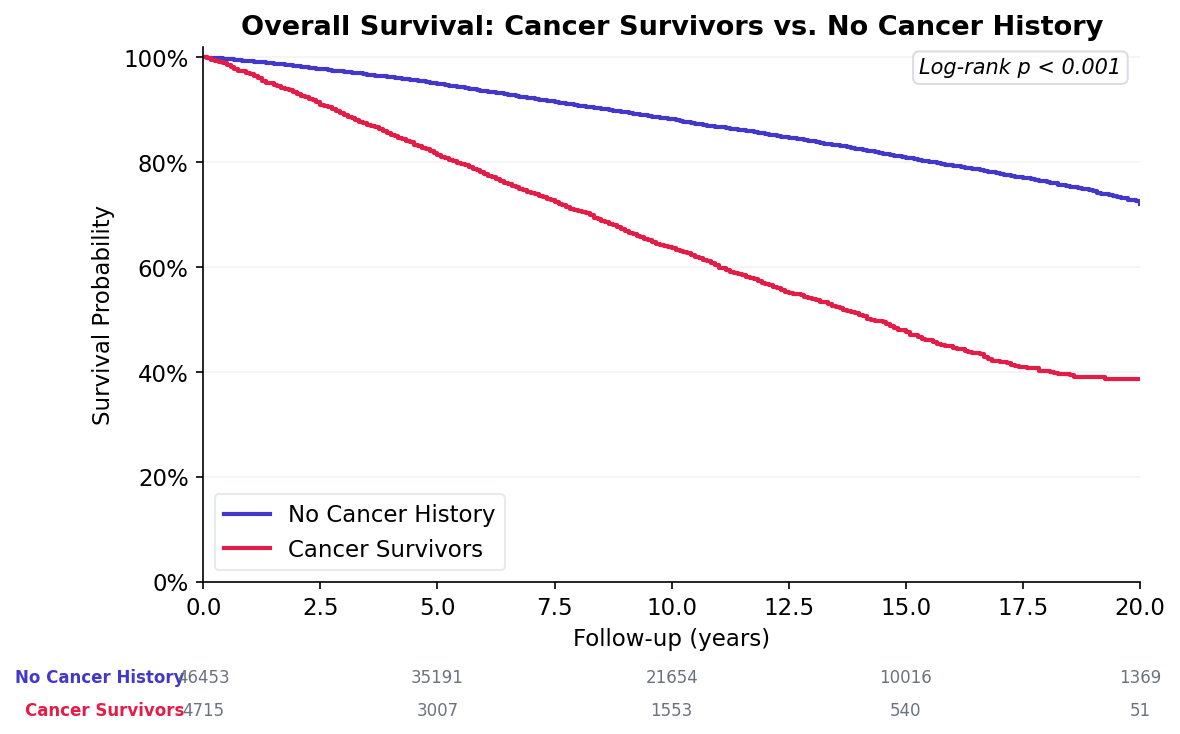

Saved: figures/km_cancer_vs_nocancer.png


In [3]:
# ============================================================
# STEP 5.3 — KM Plot 1: Cancer vs. No Cancer
# ============================================================

fig, ax = plt.subplots(figsize=(8, 6))
cancer_grp = df[df['cancer'] == 1]
no_cancer_grp = df[df['cancer'] == 0]

km_plot(ax, [no_cancer_grp, cancer_grp], 'follow_up_yrs', 'dead',
        ['No Cancer History', 'Cancer Survivors'], [COLORS[0], COLORS[1]],
        'Overall Survival: Cancer Survivors vs. No Cancer History')

plt.tight_layout(rect=[0, 0.12, 1, 1])
plt.savefig(FIG_DIR / 'km_cancer_vs_nocancer.png', bbox_inches='tight')
plt.show()
print('Saved: figures/km_cancer_vs_nocancer.png')

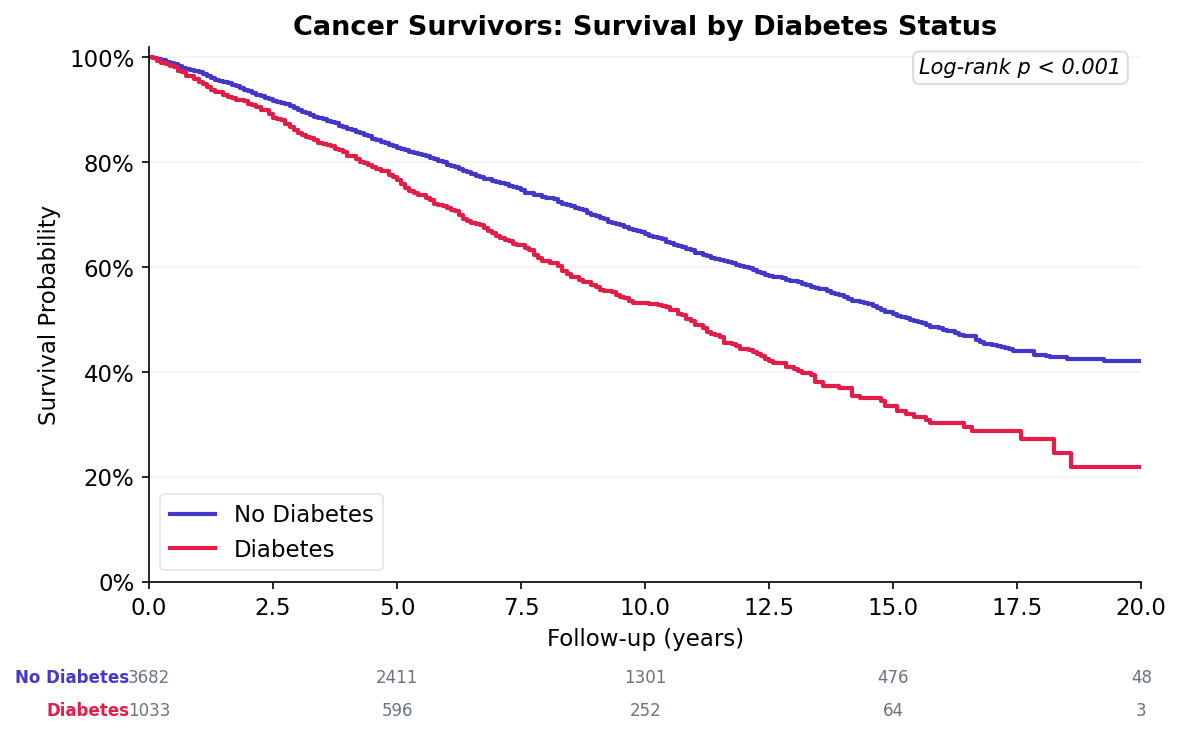

Saved: figures/km_cancer_diabetes.png


In [4]:
# ============================================================
# STEP 5.4 — KM Plot 2: Cancer survivors by DIABETES
# ============================================================

cs_diab = cancer[cancer['diabetes'] == 1]
cs_no_diab = cancer[cancer['diabetes'] == 0]

fig, ax = plt.subplots(figsize=(8, 6))
km_plot(ax, [cs_no_diab, cs_diab], 'follow_up_yrs', 'dead',
        ['No Diabetes', 'Diabetes'], [COLORS[0], COLORS[1]],
        'Cancer Survivors: Survival by Diabetes Status')

plt.tight_layout(rect=[0, 0.12, 1, 1])
plt.savefig(FIG_DIR / 'km_cancer_diabetes.png', bbox_inches='tight')
plt.show()
print('Saved: figures/km_cancer_diabetes.png')

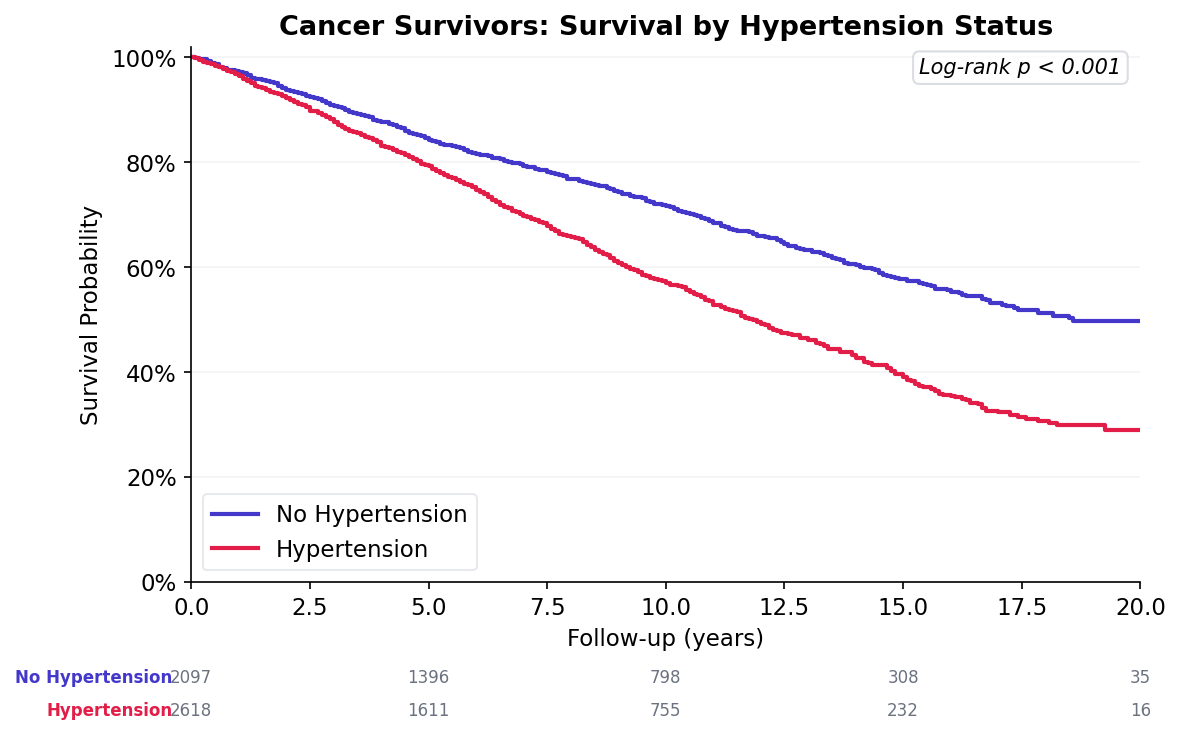

Saved: figures/km_cancer_hypertension.png


In [5]:
# ============================================================
# STEP 5.5 — KM Plot 3: Cancer survivors by HYPERTENSION
# ============================================================

cs_htn = cancer[cancer['hypertension'] == 1]
cs_no_htn = cancer[cancer['hypertension'] == 0]

fig, ax = plt.subplots(figsize=(8, 6))
km_plot(ax, [cs_no_htn, cs_htn], 'follow_up_yrs', 'dead',
        ['No Hypertension', 'Hypertension'], [COLORS[0], COLORS[1]],
        'Cancer Survivors: Survival by Hypertension Status')

plt.tight_layout(rect=[0, 0.12, 1, 1])
plt.savefig(FIG_DIR / 'km_cancer_hypertension.png', bbox_inches='tight')
plt.show()
print('Saved: figures/km_cancer_hypertension.png')

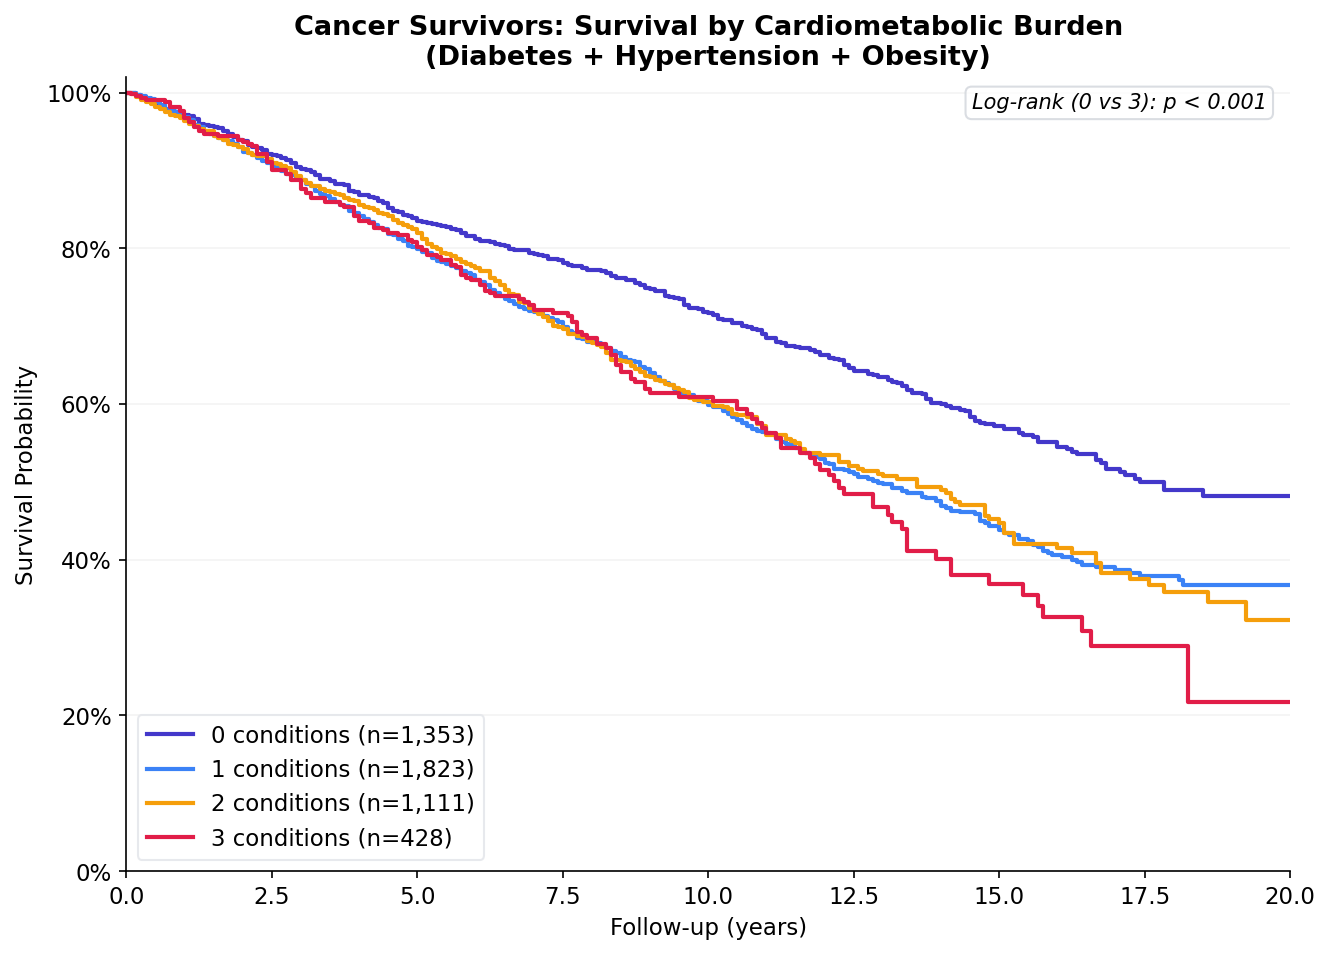

Saved: figures/km_cancer_cm_burden.png


In [6]:
# ============================================================
# STEP 5.6 — KM Plot 4: Cancer survivors by CARDIOMETABOLIC BURDEN
# ============================================================
# This is the key figure: dose-response relationship between
# number of cardiometabolic conditions and survival.

burden_groups = []
burden_labels = []
burden_colors = [COLORS[0], COLORS[4], COLORS[3], COLORS[1]]

for b in [0, 1, 2, 3]:
    grp = cancer[cancer['cm_burden'] == b]
    if len(grp) >= 20:  # minimum for meaningful curve
        burden_groups.append(grp)
        burden_labels.append(f'{b} conditions (n={len(grp):,})')

fig, ax = plt.subplots(figsize=(9, 6.5))

# Manual KM since we have >2 groups
for grp, label, color in zip(burden_groups, burden_labels, burden_colors):
    kmf = KaplanMeierFitter()
    kmf.fit(grp['follow_up_yrs'].clip(upper=20), event_observed=grp['dead'], label=label)
    kmf.plot_survival_function(ax=ax, color=color, linewidth=2, ci_show=False)

ax.set_xlim(0, 20)
ax.set_ylim(0, 1.02)
ax.set_xlabel('Follow-up (years)')
ax.set_ylabel('Survival Probability')
ax.set_title('Cancer Survivors: Survival by Cardiometabolic Burden\n(Diabetes + Hypertension + Obesity)')
ax.legend(loc='lower left', frameon=True, framealpha=0.9, edgecolor='#E5E7EB')
ax.yaxis.set_major_formatter(ticker.PercentFormatter(xmax=1))
ax.grid(axis='y', alpha=0.15)

# Log-rank trend test (0 vs 3)
if len(burden_groups) >= 2:
    g0 = burden_groups[0]
    gmax = burden_groups[-1]
    lr = logrank_test(g0['follow_up_yrs'].clip(upper=20), gmax['follow_up_yrs'].clip(upper=20),
                      g0['dead'], gmax['dead'])
    p_str = 'p < 0.001' if lr.p_value < 0.001 else f'p = {lr.p_value:.3f}'
    ax.annotate(f'Log-rank (0 vs 3): {p_str}', xy=(0.98, 0.98), xycoords='axes fraction',
                ha='right', va='top', fontsize=10, fontstyle='italic',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8, edgecolor='#D1D5DB'))

plt.tight_layout()
plt.savefig(FIG_DIR / 'km_cancer_cm_burden.png', bbox_inches='tight')
plt.show()
print('Saved: figures/km_cancer_cm_burden.png')

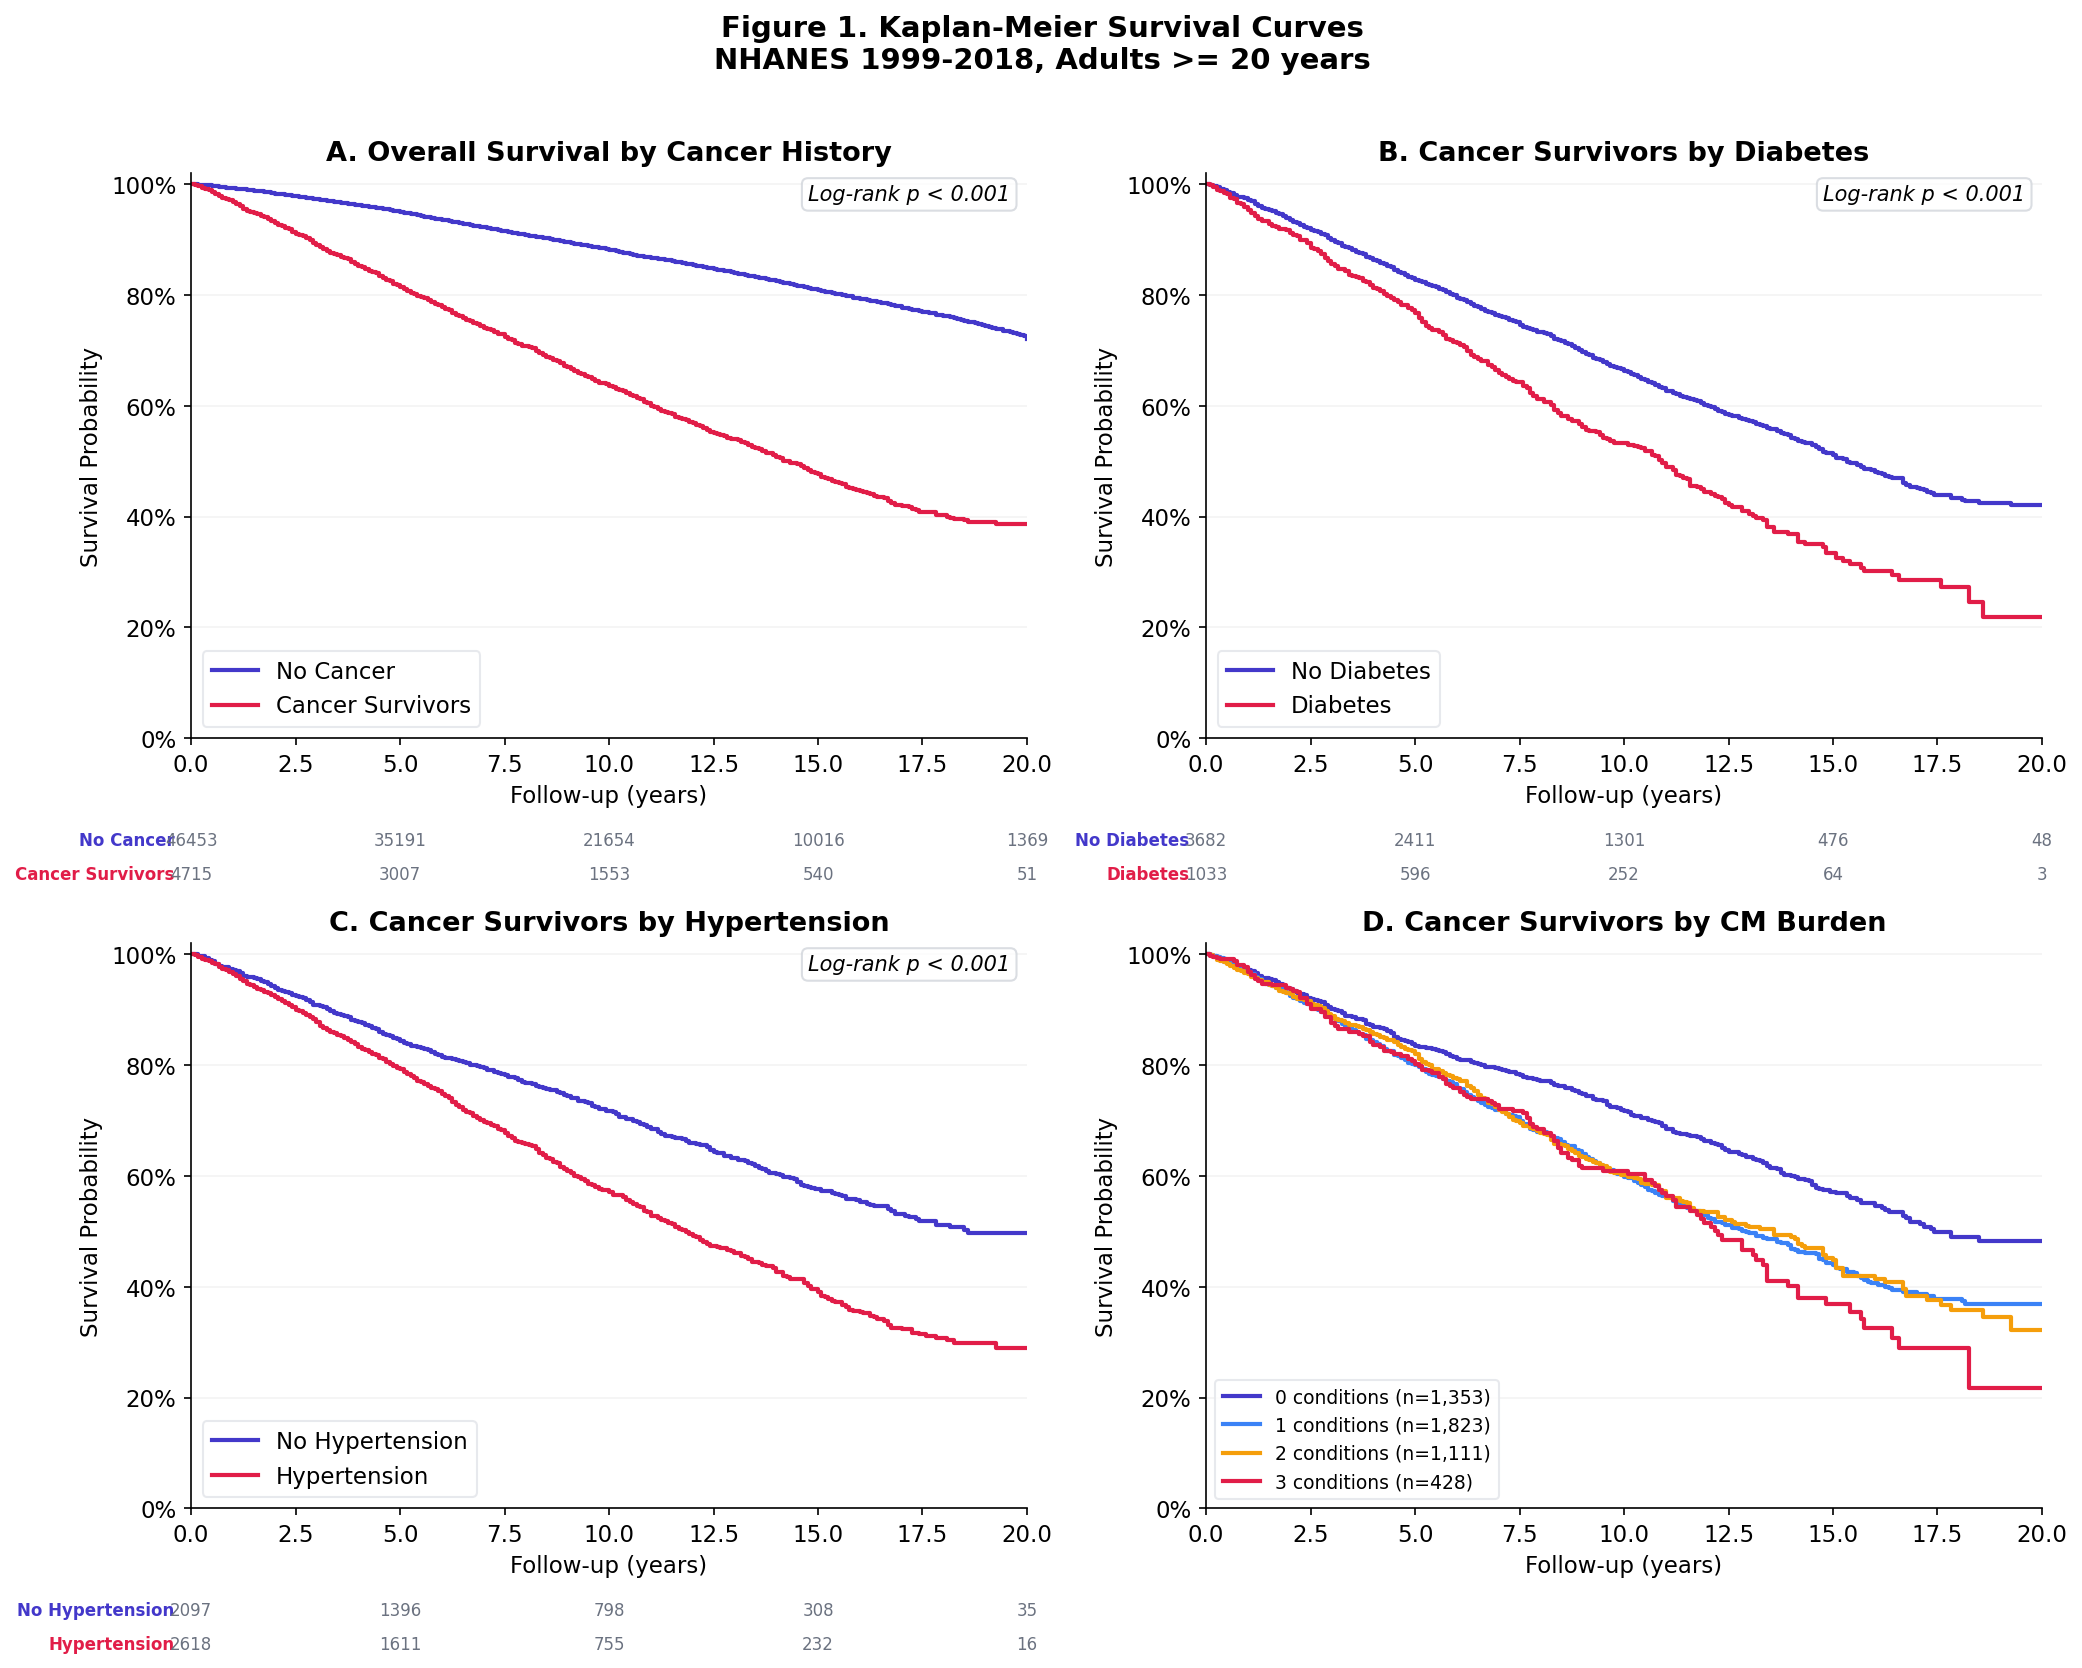

Saved: figures/km_combined_figure1.png


In [7]:
# ============================================================
# STEP 5.7 — Combined 2x2 figure for publication
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(14, 11))

# Panel A: Cancer vs No Cancer
km_plot(axes[0,0], [no_cancer_grp, cancer_grp], 'follow_up_yrs', 'dead',
        ['No Cancer', 'Cancer Survivors'], [COLORS[0], COLORS[1]],
        'A. Overall Survival by Cancer History')

# Panel B: Diabetes
km_plot(axes[0,1], [cs_no_diab, cs_diab], 'follow_up_yrs', 'dead',
        ['No Diabetes', 'Diabetes'], [COLORS[0], COLORS[1]],
        'B. Cancer Survivors by Diabetes')

# Panel C: Hypertension
km_plot(axes[1,0], [cs_no_htn, cs_htn], 'follow_up_yrs', 'dead',
        ['No Hypertension', 'Hypertension'], [COLORS[0], COLORS[1]],
        'C. Cancer Survivors by Hypertension')

# Panel D: Cardiometabolic burden
for grp, label, color in zip(burden_groups, burden_labels, burden_colors):
    kmf = KaplanMeierFitter()
    kmf.fit(grp['follow_up_yrs'].clip(upper=20), event_observed=grp['dead'], label=label)
    kmf.plot_survival_function(ax=axes[1,1], color=color, linewidth=2, ci_show=False)
axes[1,1].set_xlim(0, 20)
axes[1,1].set_ylim(0, 1.02)
axes[1,1].set_xlabel('Follow-up (years)')
axes[1,1].set_ylabel('Survival Probability')
axes[1,1].set_title('D. Cancer Survivors by CM Burden')
axes[1,1].legend(loc='lower left', frameon=True, framealpha=0.9, edgecolor='#E5E7EB', fontsize=9)
axes[1,1].yaxis.set_major_formatter(ticker.PercentFormatter(xmax=1))
axes[1,1].grid(axis='y', alpha=0.15)

plt.suptitle('Figure 1. Kaplan-Meier Survival Curves\nNHANES 1999-2018, Adults >= 20 years',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(FIG_DIR / 'km_combined_figure1.png', bbox_inches='tight')
plt.show()
print('Saved: figures/km_combined_figure1.png')

In [8]:
# ============================================================
# STEP 5.8 — Median survival estimates
# ============================================================

print('=== MEDIAN SURVIVAL ESTIMATES ===')
print()

comparisons = [
    ('Cancer vs No Cancer', [('No Cancer', no_cancer_grp), ('Cancer', cancer_grp)]),
    ('Cancer by Diabetes', [('No Diabetes', cs_no_diab), ('Diabetes', cs_diab)]),
    ('Cancer by Hypertension', [('No HTN', cs_no_htn), ('HTN', cs_htn)]),
]

for title, pairs in comparisons:
    print(f'{title}:')
    for label, grp in pairs:
        kmf = KaplanMeierFitter()
        kmf.fit(grp['follow_up_yrs'].clip(upper=20), event_observed=grp['dead'])
        med = kmf.median_survival_time_
        if np.isfinite(med):
            print(f'  {label}: median = {med:.1f} years')
        else:
            # Survival doesn't drop below 50% within follow-up
            surv_at_end = kmf.predict(20)
            print(f'  {label}: median not reached (survival at 20yr = {surv_at_end:.1%})')
    print()

print('CM Burden among cancer survivors:')
for b in [0, 1, 2, 3]:
    grp = cancer[cancer['cm_burden'] == b]
    if len(grp) >= 20:
        kmf = KaplanMeierFitter()
        kmf.fit(grp['follow_up_yrs'].clip(upper=20), event_observed=grp['dead'])
        med = kmf.median_survival_time_
        n = len(grp)
        deaths = grp['dead'].sum()
        if np.isfinite(med):
            print(f'  {b} conditions (n={n:,}, {deaths} deaths): median = {med:.1f} years')
        else:
            surv_at_end = kmf.predict(20)
            print(f'  {b} conditions (n={n:,}, {deaths} deaths): median not reached ({surv_at_end:.1%} at 20yr)')

=== MEDIAN SURVIVAL ESTIMATES ===

Cancer vs No Cancer:
  No Cancer: median not reached (survival at 20yr = 72.1%)
  Cancer: median = 14.3 years

Cancer by Diabetes:
  No Diabetes: median = 15.3 years
  Diabetes: median = 10.9 years

Cancer by Hypertension:
  No HTN: median = 18.6 years
  HTN: median = 11.8 years

CM Burden among cancer survivors:
  0 conditions (n=1,353, 417 deaths): median = 17.4 years
  1 conditions (n=1,823, 698 deaths): median = 12.9 years
  2 conditions (n=1,111, 399 deaths): median = 13.6 years
  3 conditions (n=428, 162 deaths): median = 12.2 years


---
## Step 5 Summary

### Figures Generated
1. `km_cancer_vs_nocancer.png` - Overall survival by cancer history
2. `km_cancer_diabetes.png` - Cancer survivors by diabetes
3. `km_cancer_hypertension.png` - Cancer survivors by hypertension
4. `km_cancer_cm_burden.png` - Cancer survivors by cardiometabolic burden (0-3)
5. `km_combined_figure1.png` - Publication-ready 2x2 composite

### Key Visual Findings
- Clear separation between cancer and non-cancer survival curves
- Among cancer survivors, diabetes and hypertension each independently reduce survival
- Dose-response: each additional cardiometabolic condition further reduces survival
- All differences statistically significant (log-rank p < 0.001)

### Limitations of KM
- Unadjusted: does not account for age, which is a major confounder
- Cancer survivors are older, which partly explains lower survival
- Need Cox regression to isolate independent effect of comorbidities

### Next Step
**Step 6:** Cox proportional hazards models (adjusted for age, sex, race, smoking, BMI)